# Importing

In [8]:
# %% Cell 1: Imports
from doctest import OutputChecker

import pandas as pd
import numpy as np
from darts import TimeSeries
from darts.models import ARIMA, LinearRegressionModel, RandomForest, XGBModel

seed = 24775456

import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
import pyarrow as pa
import datetime as dt
import shap

# Load Data 

In [9]:
# %% Cell 2: Load Data
def loadData():
    df = pd.read_parquet("gafanha.parquet")
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.round("h")
    print(df.count())
    return (
        df.pivot_table(index="timestamp", columns="collection", values="value", aggfunc="median")
        .asfreq("h")
        .loc[:"2024-12-31 23:00"]
        .reset_index()
    )

df = loadData()




# %% Cell 3: Readings per day per variable - for validating the dataset only
def checkDailyCount(df):
    df_daily_counts = df.set_index("timestamp").resample("D").count()

    # quick visual: counts per year for each variable
    df_daily_counts.groupby(df_daily_counts.index.year).mean().plot(
        kind="bar", figsize=(12, 5), title="Avg daily reading count per variable, by year"
    )
    plt.ylabel("avg readings/day")
    plt.tight_layout()
    plt.show()

station       916774
timestamp     916774
collection    916774
value         916774
unit          916774
source_db     916774
date          916774
values        916774
dtype: int64


In [10]:
# %% Cell 4: Force daily, median and fill in missing values with darts package
from darts.utils.missing_values import fill_missing_values
daily = df.set_index("timestamp").resample("D").median()
daily = daily.asfreq("D")

print(daily.count())


# Set up the AQI bins for each pollutant based on the standard AQI breakpoints (European standards)
aqi_bins = {
    "PM25": [-np.inf, 10, 20, 25, 50, np.inf],
    "PM10": [-np.inf, 20, 35, 50, 100, np.inf],
    "NO2":  [-np.inf, 40, 100, 200, 400, np.inf],
    "O3":   [-np.inf, 80, 120, 180, 240, np.inf],
    "SO2":  [-np.inf, 100, 200, 350, 500, np.inf],
}
sub_idx = pd.concat(
    [pd.cut(daily[p], bins=b, labels=[1, 2, 3, 4, 5]).astype(float) for p, b in aqi_bins.items()],
    axis=1,
)
daily["AQI"] = sub_idx.max(axis=1, skipna=True)
dominant = sub_idx.dropna(how="all").idxmax(axis=1)
last_valid = daily["AQI"].last_valid_index() 
print(last_valid)

# interpolates NaNs values
daily.index = daily.index.tz_localize(None)
series = TimeSeries.from_dataframe(daily, freq="D")
series = fill_missing_values(series)

collection
Benzene          2963
CO               3010
NO               2979
NO2              2979
NOx              2979
O3               3008
PM10             2632
PM25             2626
Particles        2626
Precipitation     366
Radiation         366
SO2              2990
Temperature      2635
WindDirection    3001
WindSpeed        3001
dtype: int64
2024-12-31 00:00:00+00:00


# Set up and prepare for training 3 RF Models

In [11]:
# %% Cell 5: Set targets and covariates
target = series["AQI"]
covariates = series.drop_columns(["AQI"])

# Check for NaN values in covariates (Adding guards against NaN values in covariates to prevent Random Forest model from failing)
assert not covariates.to_dataframe().isna().any().any(), "NaN in covariates, RF may fail"

In [12]:
# %% Cell 6: generic per-period pipeline
import optuna
from darts.metrics import rmse, mae, mape

def run_period(target, covariates, model_cls, param_space, fixed_param, n_trials=500, params=None):

    # Split the data into training, validation, and test sets
    y_train, y_temp = target.split_before(0.6)
    y_val, y_test = y_temp.split_before(0.5)
    x_train, x_temp = covariates.split_before(0.6)
    x_val, x_test = x_temp.split_before(0.5)

    # Tune with Optuna only if no params were given
    if params is None:
        def findParam(trial):
            p = {name: fn(trial) for name, fn in param_space.items()}
            model = model_cls(**p, **fixed_param)
            model.fit(y_train, past_covariates=x_train)
            preds = model.historical_forecasts(
                series=y_train.append(y_val), past_covariates=x_train.append(x_val),
                start=y_val.start_time(), forecast_horizon=1, stride=1,
                retrain=False, last_points_only=True, verbose=False,
            ).map(lambda x: np.round(x))
            return rmse(y_val, preds), mae(y_val, preds), mape(y_val, preds)

        # Minimise all three metrics (RMSE, MAE, MAPE) simultaneously
        study = optuna.create_study(directions=["minimize"] * 3,
                                    sampler=optuna.samplers.TPESampler(seed=seed))
        study.optimize(findParam, n_trials=n_trials, show_progress_bar=True)

        vals = np.array([t.values for t in study.best_trials])
        best = study.best_trials[np.argmin((vals / vals.min(axis=0)).sum(axis=1))]
        params = best.params

    y_fit, x_fit = y_train.append(y_val), x_train.append(x_val)
    test_pred = model_cls(**params, **fixed_param).historical_forecasts(
        series=y_fit.append(y_test), past_covariates=x_fit.append(x_test),
        start=y_test.start_time(), forecast_horizon=1, stride=1,
        retrain=True, train_length=None, last_points_only=True, verbose=False,
    ).map(lambda x: np.round(x))

    # naive = TimeSeries.from_times_and_values(
    #     y_test.time_index, target.to_series().shift(1).loc[y_test.time_index].values)

    # Fit the final model on the combined training and validation sets - for SHAP analysis and feature importance
    model = model_cls(**params, **fixed_param).fit(y_fit, past_covariates=x_fit)

    return dict(
        model=model, params=params, y=target, x=covariates, y_test=y_test, x_test=x_test, test_pred=test_pred,
        model_metrics=(rmse(y_test, test_pred), mae(y_test, test_pred), mape(y_test, test_pred)),
        # naive_metrics=(rmse(y_test, naive), mae(y_test, naive), mape(y_test, naive)),
        sizes=(len(y_train), len(y_val), len(y_test)),
    )

# For Each of the Periods

### Config the models - run search

In [13]:
# %% Cell 7: Random Forest config
import joblib

# Similar to XGBoost
rf_fixed = dict(lags=7, lags_past_covariates=7, output_chunk_length=1,
                n_jobs=-1, random_state=seed)
rf_space = dict(
    n_estimators=lambda t: t.suggest_int("n_estimators", 50, 400),
    max_depth=lambda t: t.suggest_int("max_depth", 3, 20),
    min_samples_split=lambda t: t.suggest_int("min_samples_split", 2, 10),
)

# 3 periods: pre, during, post
bounds = {"pre":    (None, "2020-02-29"),
          "during": ("2020-03-01", "2021-04-30"),
          "post":   ("2021-05-01", None)}

### Refit and recreate result

In [14]:
results = {}
for name, (s, e) in bounds.items():
    lo = pd.Timestamp(s) if s else target.start_time()
    hi = pd.Timestamp(e) if e else target.end_time()
    results[name] = run_period(target.slice(lo, hi), covariates.slice(lo, hi), RandomForest, rf_space, rf_fixed)
    r = results[name]
    print(name, r["sizes"], "model", r["model_metrics"])
    r["model"].save(f"rf_aqi_{name}.pkl")
joblib.dump(results, "results_rf.pkl")

[I 2026-09-30 23:44:46,891] A new study created in memory with name: no-name-a853a6d1-3403-49cd-92c1-4f280ba12725


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-09-30 23:44:47,620] Trial 0 finished with values: [0.8599206949088777, 0.5862068965517241, 23.735632183908045] and parameters: {'n_estimators': 305, 'max_depth': 7, 'min_samples_split': 3}.
[I 2026-09-30 23:44:47,766] Trial 1 finished with values: [0.866578244826242, 0.5977011494252874, 24.05491698595147] and parameters: {'n_estimators': 50, 'max_depth': 8, 'min_samples_split': 10}.


[I 2026-09-30 23:44:47,898] Trial 2 finished with values: [0.8621455904643299, 0.5977011494252874, 24.21455938697318] and parameters: {'n_estimators': 66, 'max_depth': 4, 'min_samples_split': 6}.


[I 2026-09-30 23:44:48,311] Trial 3 finished with values: [0.8753762190648171, 0.6053639846743295, 24.469987228607916] and parameters: {'n_estimators': 128, 'max_depth': 15, 'min_samples_split': 9}.


...

[I 2026-09-30 23:57:54,620] Trial 497 finished with values: [0.7201782532247905, 0.5111940298507462, 45.646766169154226] and parameters: {'n_estimators': 193, 'max_depth': 3, 'min_samples_split': 3}.


[I 2026-09-30 23:57:54,919] Trial 498 finished with values: [0.7201782532247905, 0.5111940298507462, 45.646766169154226] and parameters: {'n_estimators': 186, 'max_depth': 3, 'min_samples_split': 2}.


[I 2026-09-30 23:57:55,228] Trial 499 finished with values: [0.7227641798688508, 0.5149253731343284, 46.01990049751243] and parameters: {'n_estimators': 198, 'max_depth': 3, 'min_samples_split': 3}.


post (804, 268, 269) model (np.float64(0.3807642481108293), np.float64(0.1449814126394052), np.float64(10.966542750929367))


['results_rf.pkl']

### Rebuild result for later use - Run once - Run after the initial training (Break if not)

In [23]:
p = pd.read_csv("report_params_rf.csv", index_col=0)
p[["n_estimators", "max_depth", "min_samples_split"]] = p[["n_estimators", "max_depth", "min_samples_split"]].astype(int)
pp = p.to_dict("index")

results = {}
for name, (s, e) in bounds.items():
    lo = pd.Timestamp(s) if s else target.start_time()
    hi = pd.Timestamp(e) if e else target.end_time()
    results[name] = run_period(target.slice(lo, hi), covariates.slice(lo, hi),
                               RandomForest, None, rf_fixed, params=pp[name])
    print(name, results[name]["model_metrics"])
joblib.dump(results, "results_rf.pkl")

pre (np.float64(0.8632769823694904), np.float64(0.6007604562737643), np.float64(41.09632446134348))
during (np.float64(0.8892118276421005), np.float64(0.5813953488372093), np.float64(31.608527131782946))
post (np.float64(0.3807642481108293), np.float64(0.1449814126394052), np.float64(10.966542750929367))


['results_rf.pkl']

# Cross Validation between models

### Load the models

In [24]:
results = joblib.load("results_rf.pkl")

In [26]:
# %% Cell 8: cross-evaluation
def score(model, y_w):
    end = y_w.end_time()
    p = model.historical_forecasts(
        series=target.slice(target.start_time(), end),
        past_covariates=covariates.slice(covariates.start_time(), end),
        start=y_w.start_time(), forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False,
    ).map(lambda x: np.round(x))
    return rmse(y_w, p), mae(y_w, p)

cross = pd.DataFrame(
    {test: {f"{m}-model": score(results[m]["model"], results[test]["y_test"])[0]
            for m in results}
     for test in results}
).round(3)
cross.index.name, cross.columns.name = "model", "test window (RMSE)"
print(cross)

test window (RMSE)    pre  during   post
model                                   
pre-model           0.863   0.785  0.888
during-model        0.919   0.842  0.881
post-model          0.848   0.821  0.381


# Report, SHAP and other analysis visualisation

In [27]:
# %% Cell 9: report
report = pd.DataFrame([
    dict(period=name, model="rf", rmse=r["model_metrics"][0], mae=r["model_metrics"][1],
         mape=r["model_metrics"][2], **dict(zip(("train", "val", "test"), r["sizes"])))
    for name, r in results.items()
])
params = pd.DataFrame({name: r["params"] for name, r in results.items()}).T

print(report.round(3).to_string(index=False))
print(params)
report.to_csv("report_metrics_rf.csv", index=False)
params.to_csv("report_params_rf.csv")

period model  rmse   mae   mape  train  val  test
   pre    rf 0.863 0.601 41.096    784  261   263
during    rf 0.889 0.581 31.609    255   85    86
  post    rf 0.381 0.145 10.967    804  268   269
        n_estimators  max_depth  min_samples_split
pre               51          7                  2
during           369          5                  5
post             197          3                  5


['AQI', 'Benzene', 'CO', 'NO', 'NO2', 'NOx', 'O3', 'PM10', 'PM25', 'Particles', 'Precipitation', 'Radiation', 'SO2', 'Temperature', 'WindDirection', 'WindSpeed']


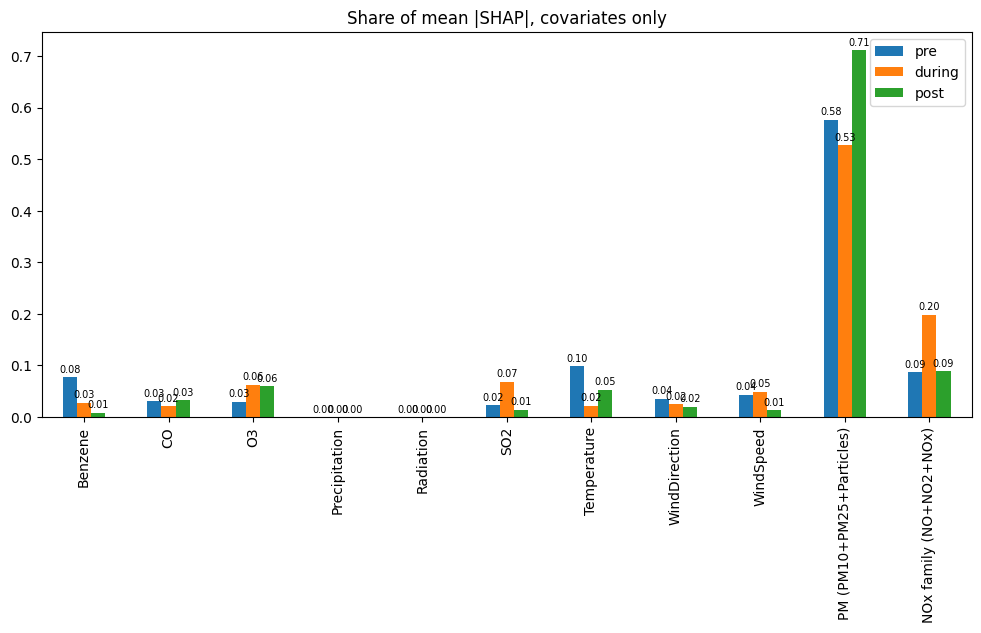

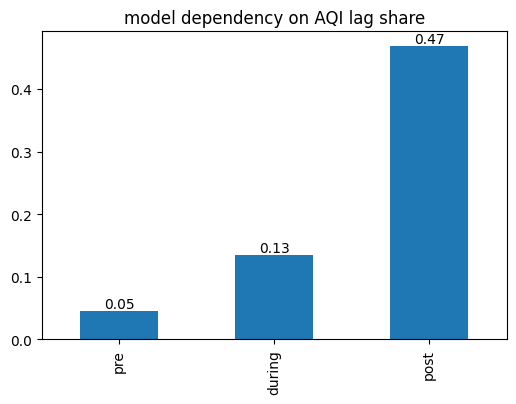

Currently Radiation and Prepicipitation are having no data until 2024 -> they are still included but this is a limitation of the dataset. The model is not able to learn from these variables and they are not contributing to the prediction.


In [28]:
# %% Cell 10: SHAP per period
import re
from darts.explainability import ShapExplainer
import warnings
warnings.filterwarnings("ignore")


import logging
logging.getLogger("darts").setLevel(logging.ERROR)



def var_importance(r):
    res = ShapExplainer(r["model"]).explain(
        foreground_series=r["y"], foreground_past_covariates=r["x"])
    sv = res.get_explanation(horizon=1, component="AQI").to_dataframe()
    
    # mean |SHAP| on test days
    sv = sv.loc[r["y_test"].time_index].abs().mean()      
    return sv.groupby(lambda c: re.sub(r"_(target|pastcov)_lag-\d+$", "", c)).sum()

imp = pd.DataFrame({name: var_importance(r) for name, r in results.items()})

# check names match the regex
print(imp.index.tolist())      

# Grouping variables into families for better visualisation
groups = {"PM (PM10+PM25+Particles)": ["PM10", "PM25", "Particles"],
          "NOx family (NO+NO2+NOx)": ["NO", "NO2", "NOx"]}

def grouped(imp):
    g = imp.drop("AQI")
    for name, cols in groups.items():
        g.loc[name] = g.loc[cols].sum()
        g = g.drop(cols)
    return g / g.sum()


# Plot the graphs
share = grouped(imp)
ax = share.plot.bar(figsize=(12, 5), title="Share of mean |SHAP|, covariates only")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()

ax = (imp.loc["AQI"] / imp.sum()).plot.bar(figsize=(6, 4), title="model dependency on AQI lag share")
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.show()
print(f"Currently Radiation and Prepicipitation are having no data until 2024 -> they are still included but this is a limitation of the dataset. The model is not able to learn from these variables and they are not contributing to the prediction.")

### Tested variable impacts of 3 models in same period

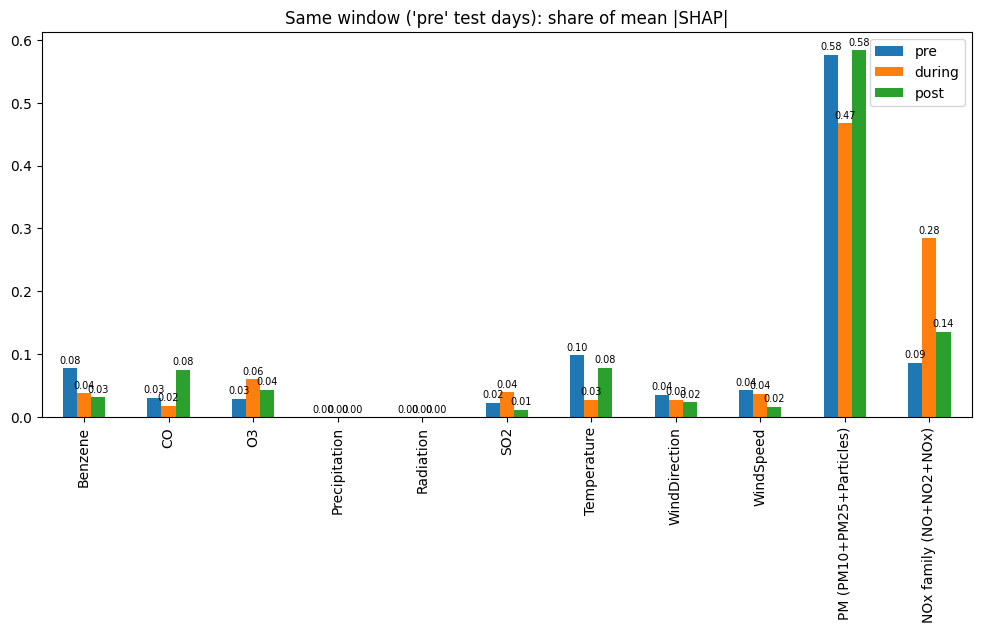

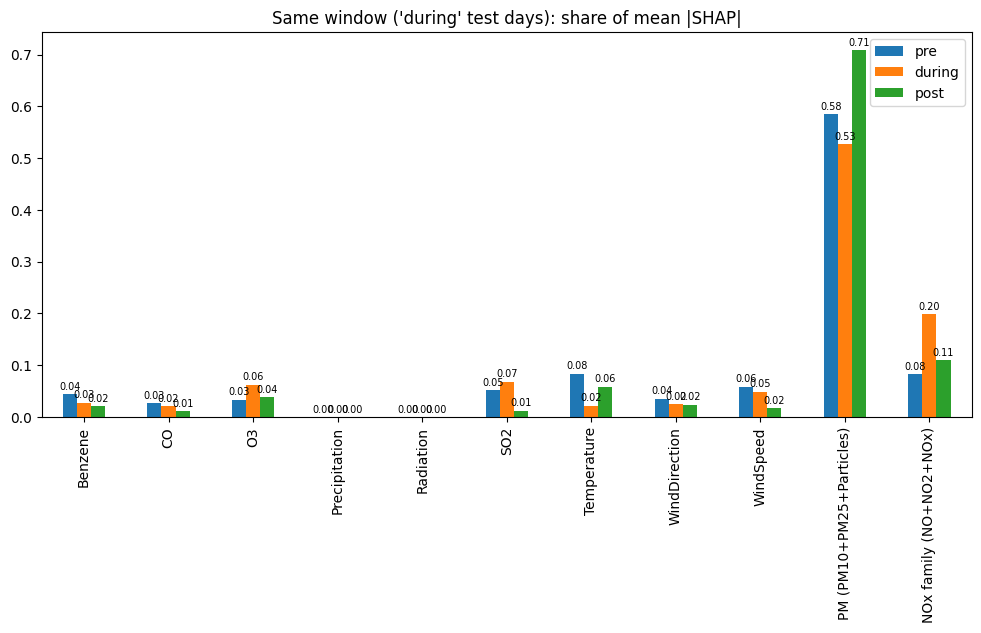

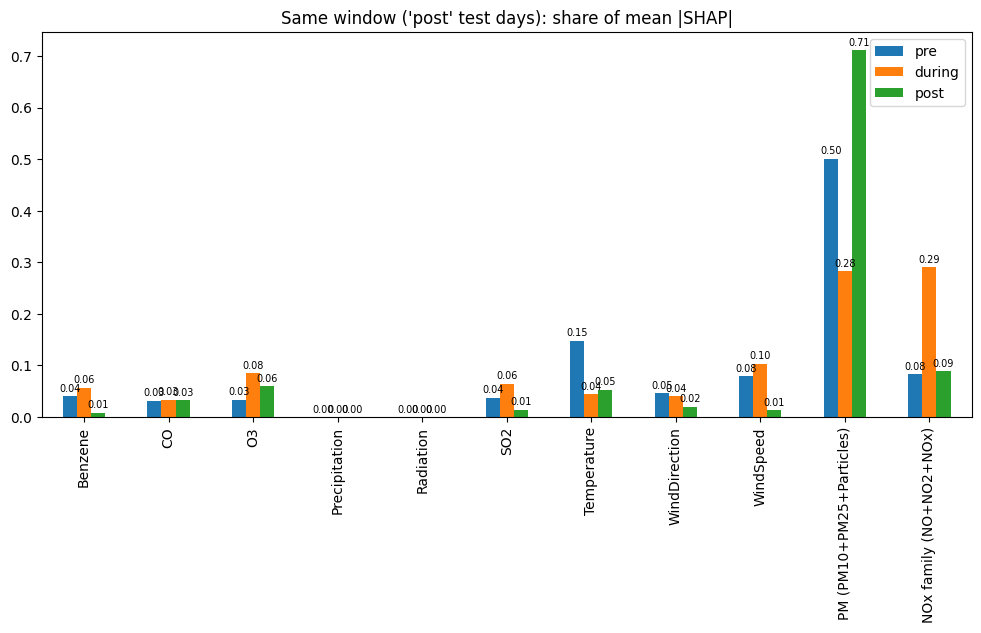

In [29]:
# %% Cell 12: SHAP, all 3 models on the same window
def var_importance_on(model, y_w, days=14):
    lo, hi = y_w.start_time() - pd.Timedelta(days=days), y_w.end_time()
    res = ShapExplainer(model).explain(
        foreground_series=target.slice(lo, hi),
        foreground_past_covariates=covariates.slice(lo, hi))
    sv = res.get_explanation(horizon=1, component="AQI").to_dataframe()
    sv = sv.loc[y_w.time_index].abs().mean()
    return sv.groupby(lambda c: re.sub(r"_(target|pastcov)_lag-\d+$", "", c)).sum()

# Currentlyt using the post period as the window for comparison, but can be changed to pre or during
y_w = results["pre"]["y_test"]
same = pd.DataFrame({m: var_importance_on(r["model"], y_w) for m, r in results.items()})
same_share = grouped(same)

ax = same_share.plot.bar(figsize=(12, 5),
    title=f"Same window ('{[k for k,v in results.items() if v['y_test'] is y_w][0]}' test days): share of mean |SHAP|")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()


y_w = results["during"]["y_test"]
same = pd.DataFrame({m: var_importance_on(r["model"], y_w) for m, r in results.items()})
same_share = grouped(same)

ax = same_share.plot.bar(figsize=(12, 5),
    title=f"Same window ('{[k for k,v in results.items() if v['y_test'] is y_w][0]}' test days): share of mean |SHAP|")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()


y_w = results["post"]["y_test"]
same = pd.DataFrame({m: var_importance_on(r["model"], y_w) for m, r in results.items()})
same_share = grouped(same)

ax = same_share.plot.bar(figsize=(12, 5),
    title=f"Same window ('{[k for k,v in results.items() if v['y_test'] is y_w][0]}' test days): share of mean |SHAP|")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()

### Beeswarm visualisation of variable impact

Note: Each node is the sum of SHAP value for all 7 lags, color is for lag-1 (day before)

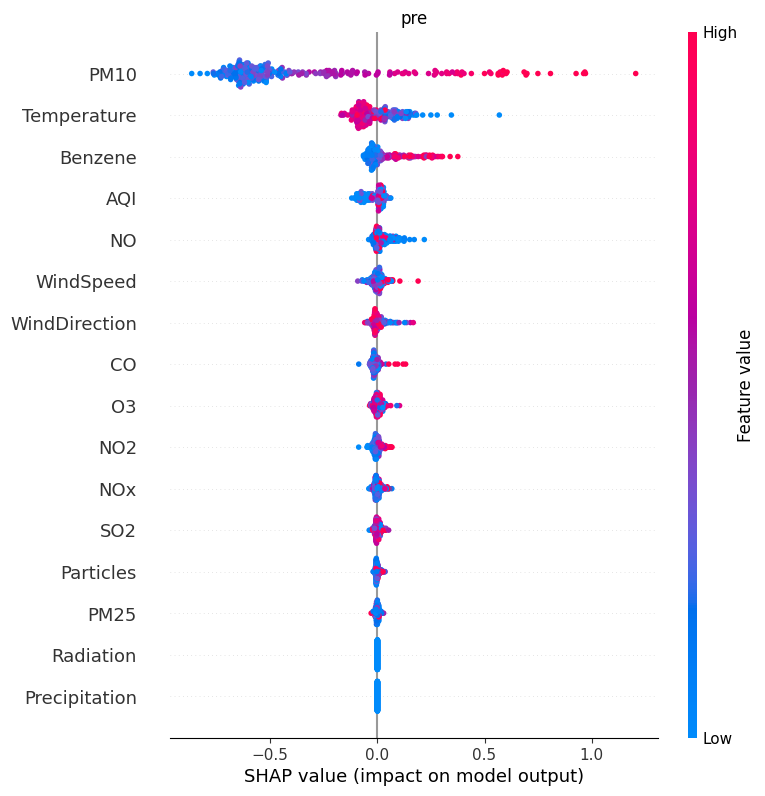

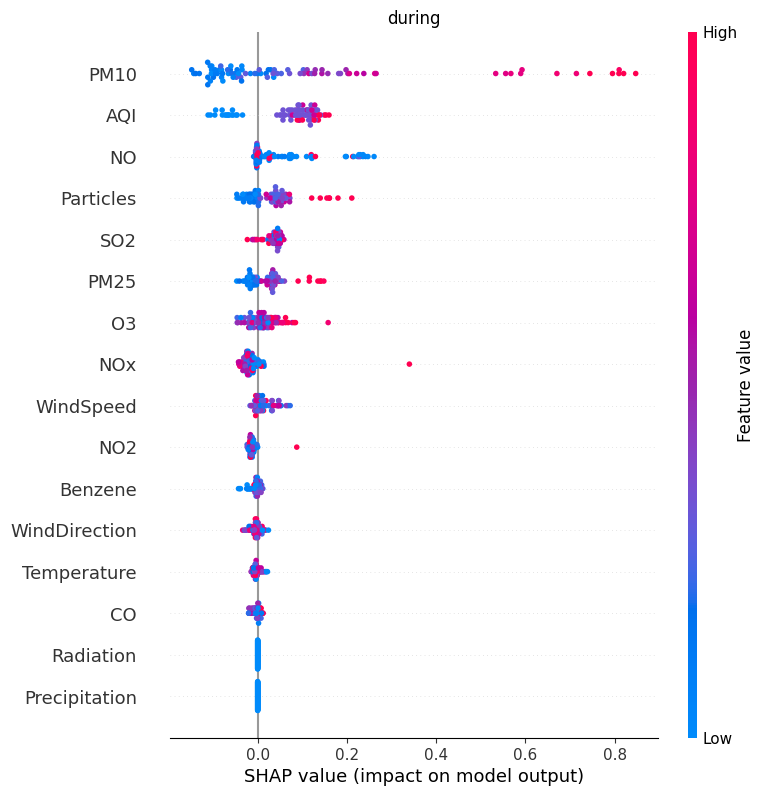

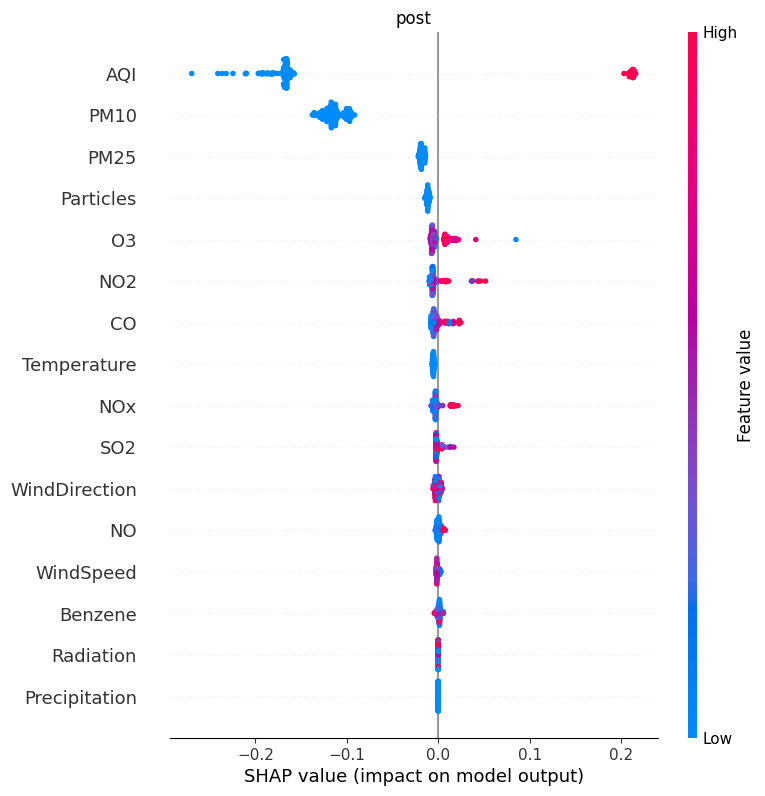

In [30]:
def beeswarm(r):
    res = ShapExplainer(r["model"]).explain(
        foreground_series=r["y"], foreground_past_covariates=r["x"])
    idx = r["y_test"].time_index
    sv = res.get_explanation(horizon=1, component="AQI").to_dataframe().loc[idx]
    fv = res.get_feature_values(horizon=1, component="AQI").to_dataframe().loc[idx]
    strip = lambda c: re.sub(r"_(target|pastcov)_lag-\d+$", "", c)

    # Group the SHAP values and feature values by variable name (removing the lag suffix)
    sv = sv.T.groupby(strip).sum().T
    fv = fv.filter(regex=r"_lag-1$").rename(columns=strip)[sv.columns]
    return sv, fv

for name, r in results.items():
    sv, fv = beeswarm(r)
    shap.summary_plot(sv.values, fv, show=False)
    plt.title(name)
    plt.show()

### Line graph for models' prediction vs actual data

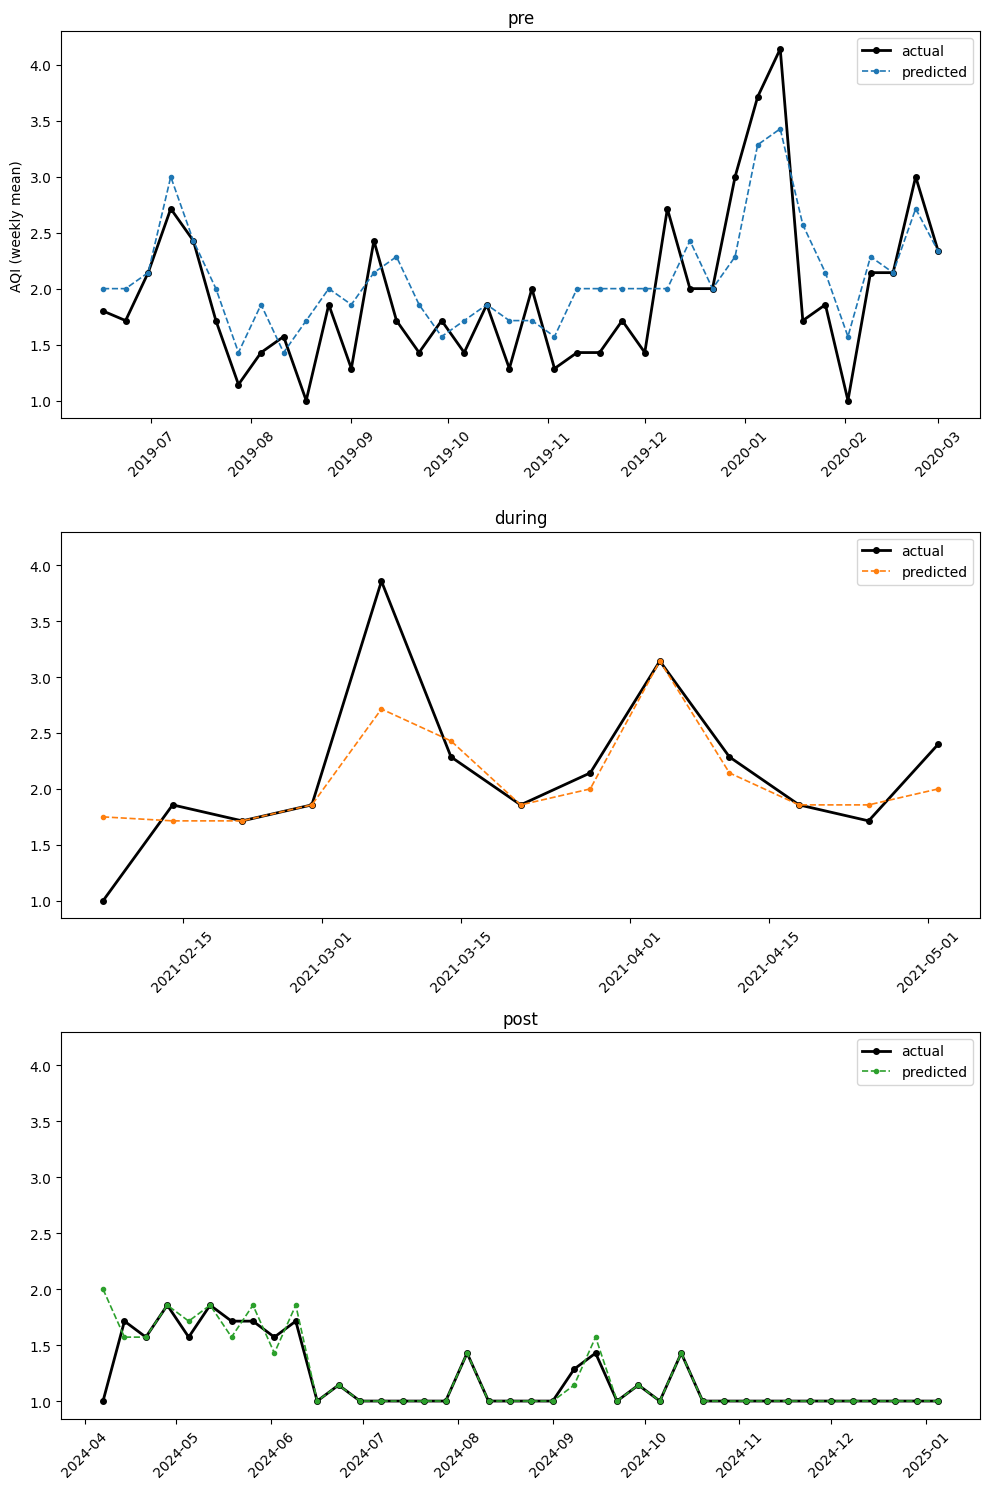

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharey=True)
colors = dict(pre="tab:blue", during="tab:orange", post="tab:green")

for ax, (name, r) in zip(axes, results.items()):
    actual_w = r["y_test"].to_series().resample("W").mean()
    pred_w = r["test_pred"].to_series().resample("W").mean()

    ax.plot(actual_w.index, actual_w.values, color="black", lw=2, marker="o", markersize=4, label="actual", zorder=2)
    ax.plot(pred_w.index, pred_w.values, color=colors[name], lw=1.2, marker="o", markersize=3,
        linestyle="--", label="predicted", zorder=3)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

    

axes[0].set_ylabel("AQI (weekly mean)")
plt.tight_layout()
plt.show()